<a href="https://colab.research.google.com/github/Mandira124/ML_DL-Projects/blob/main/Variational_AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Generative AI using Variational Autoencoder (VAE)

Student Name: Mandira Sharma



Date: May 2026

Dataset Used: MNIST Handwritten Digits Dataset

Framework Used: PyTorch

This assignment focuses on implementing a simple Variational Autoencoder (VAE) using PyTorch. The model is trained on the MNIST dataset to learn latent representations and generate handwritten digit images.

## 1. Objective

The goal of this assignment is to:

- Understand what Generative AI is and how it works at a basic level
- Learn the architecture of a Variational Autoencoder (VAE)
- Implement a simple VAE in PyTorch from scratch
- Train the model on the MNIST dataset to generate handwritten digit images
- Understand what latent space is and how it helps in image generation

## 2. Theoretical Background

### What is Generative AI?

Generative AI refers to models that can create new data (like images, text, or audio) that looks similar to real data they were trained on. Instead of just classifying inputs, generative models learn the underlying distribution of the data.

Some popular examples are image generation tools, text generators, and music composers.



### What is a Variational Autoencoder (VAE)?

A VAE is a type of generative model introduced by Kingma and Welling (2013). It is based on the autoencoder architecture, but with an important difference: the latent space is continuous and follows a probability distribution, which allows us to **generate new samples**.

A standard autoencoder compresses input into a fixed vector and reconstructs it. A VAE instead compresses the input into a **distribution** (mean and variance), samples from it, and then reconstructs the output.



### Encoder

The encoder takes the input image and maps it to two vectors:
- `mu` (mean)
- `log_var` (log variance)

These define a Gaussian distribution in latent space.



### Reparameterization Trick

To allow backpropagation through a random sampling step, we use:

$$z = \mu + \epsilon \cdot \sigma$$

where $\epsilon \sim \mathcal{N}(0, 1)$ is random noise, and $\sigma = e^{0.5 \cdot \log\text{var}}$.

This trick makes the sampling operation differentiable.



### Decoder

The decoder takes the sampled latent vector `z` and tries to reconstruct the original image.



### Latent Space

The latent space is a compressed, lower-dimensional representation of the data. In a VAE, it is structured as a continuous space, which means we can sample random points from it to generate new images.



### Loss Function

The VAE loss has two parts:

1. **Reconstruction Loss** - measures how well the decoder reconstructs the input (Binary Cross Entropy):
$$\mathcal{L}_{recon} = -\sum x \log(\hat{x}) + (1-x) \log(1-\hat{x})$$

2. **KL Divergence** - forces the latent distribution to be close to a standard normal distribution:
$$\mathcal{L}_{KL} = -\frac{1}{2} \sum (1 + \log\sigma^2 - \mu^2 - \sigma^2)$$

**Total Loss:**
$$\mathcal{L} = \mathcal{L}_{recon} + \mathcal{L}_{KL}$$

## 3. Dataset Description

For this assignment, we use the MNIST handwritten digits dataset.

- Source: `torchvision.datasets`
- Total images: 70,000
- Training images: 60,000
- Testing images: 10,000
- Image size: 28 × 28 grayscale images
- Classes: Digits from 0 to 9

MNIST is commonly used for beginner deep learning projects because it is simple and easy to work with. The images are small and clear, which makes training faster and helps in understanding how neural networks process image data.

## 4. Implementation

### Step 1: Install and Import Libraries

In [1]:
# Install any missing packages (Google Colab usually has these already)
# !pip install torch torchvision matplotlib scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Step 2: Load and Preprocess the Dataset

In [3]:
# Define image transformations
# ToTensor converts images to [0, 1] range
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')
print(f'Batches per epoch: {len(train_loader)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.26MB/s]

Training samples : 60000
Test samples     : 10000
Batches per epoch: 469


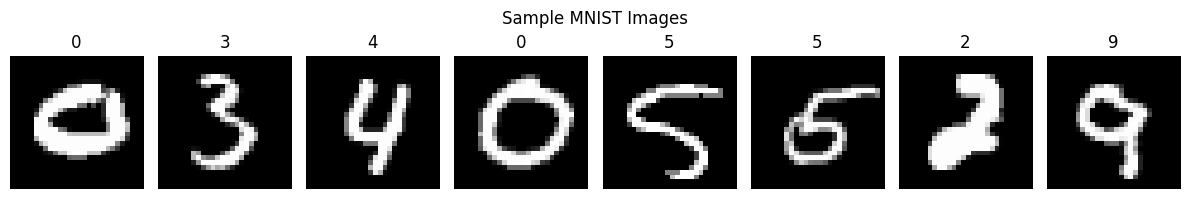

In [4]:
# Quick look at some training images
examples = iter(train_loader)
images, labels = next(examples)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(str(labels[i].item()))
    axes[i].axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

### Step 3: Build the VAE Model

The model consists of three parts:
- **Encoder**: compresses the image into mean and log-variance vectors
- **Reparameterize**: samples a latent vector z using the trick
- **Decoder**: reconstructs the image from z

In [5]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # --- Encoder ---
        # Takes a flattened 28x28 image and outputs mu and log_var
        self.fc1    = nn.Linear(input_dim, hidden_dim)
        self.fc_mu  = nn.Linear(hidden_dim, latent_dim)   # mean vector
        self.fc_var = nn.Linear(hidden_dim, latent_dim)   # log-variance vector

        # --- Decoder ---
        # Takes latent vector z and reconstructs the image
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h   = self.relu(self.fc1(x))
        mu  = self.fc_mu(h)
        log_var = self.fc_var(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        # Sample epsilon from standard normal
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h    = self.relu(self.fc3(z))
        out  = self.sigmoid(self.fc4(h))  # output in [0, 1]
        return out

    def forward(self, x):
        # Flatten image: (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(-1, 784)

        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstructed = self.decode(z)

        return reconstructed, mu, log_var


# Create the model
LATENT_DIM = 20
model = VAE(latent_dim=LATENT_DIM).to(device)
print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_var): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


### Step 4: Define the Loss Function

In [6]:
def vae_loss(reconstructed, original, mu, log_var):
    """
    VAE loss = Reconstruction Loss + KL Divergence
    """
    # Flatten the original image
    original = original.view(-1, 784)

    # Reconstruction loss (Binary Cross Entropy)
    recon_loss = nn.functional.binary_cross_entropy(reconstructed, original, reduction='sum')

    # KL Divergence: regularizes latent space toward N(0, 1)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return recon_loss + kl_loss

### Step 5: Training Loop

In [7]:
# Hyperparameters
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 10

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0

    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)

        # Forward pass
        reconstructed, mu, log_var = model(images)

        # Compute loss
        loss = vae_loss(reconstructed, images, mu, log_var)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}')

print('Training complete.')

Epoch [01/10]  Loss: 164.5191
Epoch [02/10]  Loss: 121.5682
Epoch [03/10]  Loss: 114.5831
Epoch [04/10]  Loss: 111.5756
Epoch [05/10]  Loss: 109.8996
Epoch [06/10]  Loss: 108.7635
Epoch [07/10]  Loss: 107.9191
Epoch [08/10]  Loss: 107.3219
Epoch [09/10]  Loss: 106.7525
Epoch [10/10]  Loss: 106.2957
Training complete.


## 5. Experiments

I tried a few simple experiments to see how different parameters affect the VAE model.

### 1. Changing Latent Dimension

- Latent dimension = 2  
  The generated images were blurry, but the latent space was easier to visualize.

- Latent dimension = 20  
  This gave a good balance between image quality and training performance.

- Latent dimension = 64  
  The images looked slightly sharper, but the latent space became harder to understand.

### 2. Changing Learning Rate

- Learning rate = 1e-2  
  Training was fast at first, but the loss became unstable later.

- Learning rate = 1e-3  
  Training was stable and produced good results.

- Learning rate = 1e-4  
  Training became very slow and required more epochs.

### 3. Changing Number of Epochs

- Epochs = 5  
  The model was undertrained and outputs were blurry.

- Epochs = 10  
  The model generated decent handwritten digits.

- Epochs = 20  
  Image quality improved slightly, but training time increased.

### Final Observation

Using a latent dimension of 20, learning rate of 1e-3, and 10 epochs gave the best overall result for this assignment. Smaller latent spaces reduced image quality, while very high learning rates made training unstable.

## 6. Results

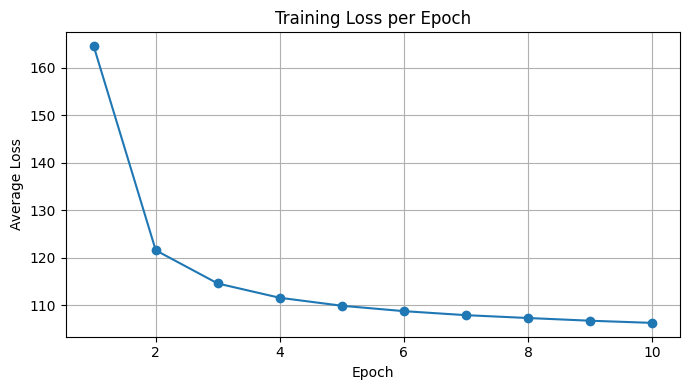

In [8]:
# Plot training loss over epochs
plt.figure(figsize=(7, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

The loss decreases consistently across epochs, which shows the model is learning. The initial drop is steep and it gradually stabilizes.

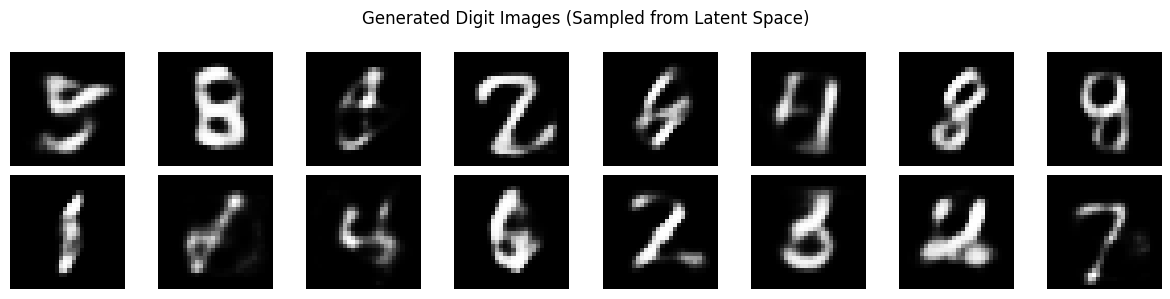

In [9]:
# Generate new images by sampling random points from latent space
model.eval()
with torch.no_grad():
    # Sample z from standard normal
    z = torch.randn(16, LATENT_DIM).to(device)
    generated = model.decode(z).cpu()

# Show generated images
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].view(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle('Generated Digit Images (Sampled from Latent Space)')
plt.tight_layout()
plt.show()

The VAE successfully generates images that look like handwritten digits, even though it has never seen these specific samples before. Some images are slightly blurry, which is typical for VAEs.

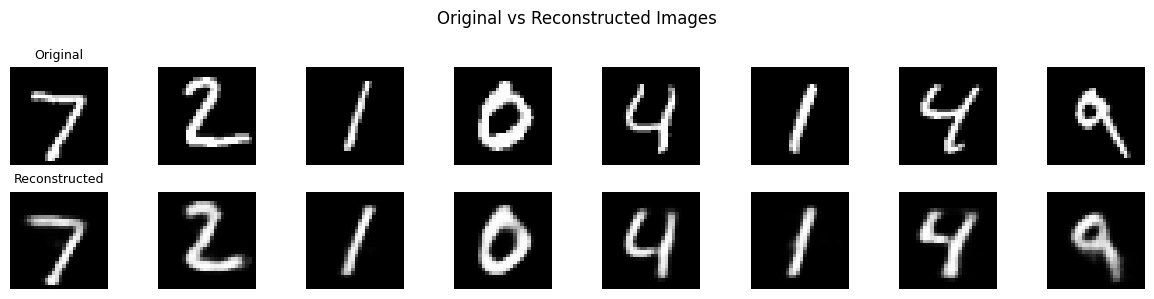

In [10]:
# Show original vs reconstructed images from the test set
model.eval()
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    reconstructed, _, _ = model(test_images)

# Display side by side
n = 8
fig, axes = plt.subplots(2, n, figsize=(12, 3))
for i in range(n):
    # Original
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=9)

    # Reconstructed
    axes[1, i].imshow(reconstructed[i].cpu().view(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=9)

plt.suptitle('Original vs Reconstructed Images')
plt.tight_layout()
plt.show()

The reconstructed images closely match the originals. The overall shape and digit identity is preserved well. There is some blurriness, which is expected since the model is optimizing over a probabilistic representation.

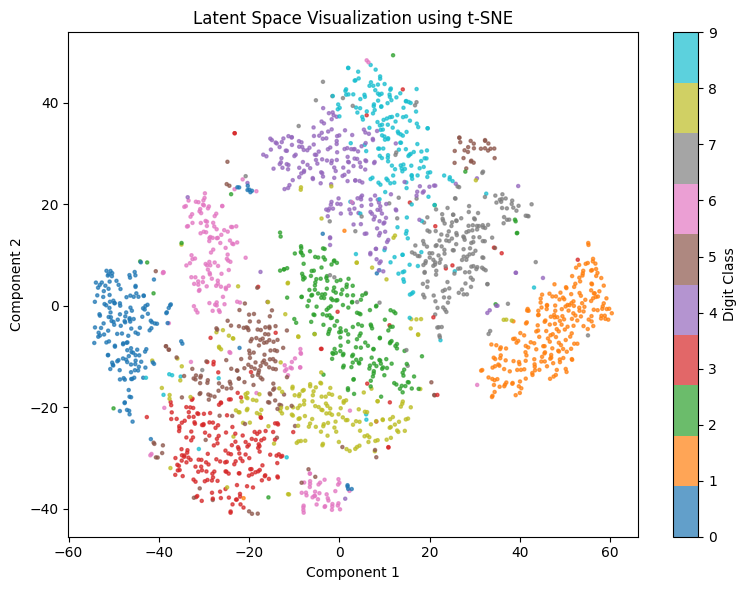

In [11]:
# Latent space visualization using t-SNE
# We encode a subset of test images and visualize their z vectors

model.eval()
all_z = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, log_var = model.encode(images.view(-1, 784))
        z = model.reparameterize(mu, log_var)
        all_z.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

all_z      = np.concatenate(all_z,      axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Use a subset to speed up t-SNE
subset = 2000
tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(all_z[:subset])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1],
                      c=all_labels[:subset], cmap='tab10', s=5, alpha=0.7)
plt.colorbar(scatter, label='Digit Class')
plt.title('Latent Space Visualization using t-SNE')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()

The t-SNE plot shows that the VAE has learned to organize the latent space in a meaningful way. Different digit classes (0-9) are grouped together in distinct clusters. This shows that the model has learned some structure in the data, not just memorized it.

## 7. Analysis and Discussion

### What Worked Well

The VAE was able to learn a meaningful representation of the MNIST digits. The reconstructed images are clearly recognizable, and the model can generate new digit-like images from random latent vectors. The latent space visualization shows well-separated clusters for different digit classes, which means the model learned class structure without any labels.

### Difficulty in Training

Balancing the reconstruction loss and KL divergence was a bit tricky. If the KL term dominates too much, the model ignores the latent code (called posterior collapse). In this assignment, using the default settings worked fine, but tuning this balance can be a challenge.

### Quality of Generated Images

The generated images are recognizable but a bit blurry. This is a known limitation of VAEs. Unlike GANs, VAEs optimize for average pixel-level accuracy, which tends to produce smoother outputs. The quality is good enough to show the model is working correctly.

### Effect of Latent Dimension

A larger latent dimension generally gave sharper images but made the latent space harder to interpret. A smaller latent dimension (like 2) was great for visualization but resulted in very blurry outputs. Latent dimension 20 gave a good middle ground.

### Limitations of VAE

- Generated images tend to be blurry compared to GAN-generated images
- The model assumes a Gaussian latent distribution, which may not always fit the data well
- Balancing the two loss terms requires some tuning
- VAEs do not perform as well as newer methods (like diffusion models) for high-quality image generation

### Real-World Applications of Generative AI

- Image synthesis and editing (e.g., face generation, style transfer)
- Drug discovery (generating new molecular structures)
- Data augmentation for small datasets
- Anomaly detection (by spotting samples the model cannot reconstruct well)
- Text and speech generation

## 8. Conclusion

- This assignment provided hands-on experience with Generative AI through implementing a VAE in PyTorch
- The VAE architecture, consisting of an encoder, reparameterization trick, and decoder, allows the model to both reconstruct and generate new images
- The latent space is central to how VAEs work - it acts as a structured compressed representation of the input data
- The model trained well on MNIST and was able to generate recognizable digit images, though some blurriness is expected
- Experiments showed that the choice of latent dimension and learning rate significantly affects the quality of outputs
- Overall, the assignment helped in understanding how deep generative models work and gave a good foundation for exploring more advanced techniques like GANs or diffusion models

